# Video → tour 3D kiểu Matterport trên Colab
Notebook độc lập: clone repo public [`nguyennguyenphuc/3D-ify-everything`](https://github.com/nguyennguyenphuc/3D-ify-everything/tree/feature/courtyard-studio) (không cần token), chạy từng model một và hiện kết quả trung gian.
Chạy tuần tự từ trên xuống; mỗi bước lưu kết quả, nên chạy lại chỉ làm tiếp phần chưa xong.

## Model dùng trong pipeline
| Bước | Model / công cụ | Nguồn | Vai trò |
|---|---|---|---|
| 1 | FFmpeg + ORB/RANSAC (OpenCV) | `studio/sources.py`, `studio/selection.py` | Trích frame, bỏ ảnh mờ/trùng, kiểm tra các frame liền nhau có vùng chung |
| 2 | **VGGT-1B** (Meta) | [`facebook/VGGT-1B`](https://huggingface.co/facebook/VGGT-1B), repo `facebookresearch/vggt` | Một lần suy luận cho mọi frame: vị trí camera + depth → point cloud + COLMAP |
| 2b | VGGSfM tracker + **pycolmap bundle adjustment** (`demo_colmap.py --use_ba` của VGGT, môi trường Python 3.11 riêng) | repo `facebookresearch/vggt` | Tinh chỉnh pose camera (`POSE_BA`) |
| 3a | **3DGUT** (3DGRUT, NVIDIA), chiến lược MCMC | submodule `3DGRUT-ArtiFixer` của ArtiFixer | Train Gaussian Splat gốc từ ảnh thật (train riêng cho cảnh này, không có trọng số sẵn) |
| 3b | **MoGe-2** (Microsoft) | `microsoft/MoGe` | Ước lượng scale theo mét cho điều kiện camera của ArtiFixer |
| 3c | Text encoder **umt5** của Wan2.1 | `Wan-AI/Wan2.1-T2V-1.3B-Diffusers` | Mã hoá một caption cố định (thay Qwen3-VL-30B của ArtiFixer) |
| 3d | **ArtiFixer 1.3B** (NVIDIA, SIGGRAPH 2026) | [`nv-tlabs/ArtiFixer`](https://github.com/nv-tlabs/ArtiFixer) @ `a392c4d`, checkpoint [`nvidia/ArtiFixer`](https://huggingface.co/nvidia/ArtiFixer) trên nền Wan2.1-T2V-1.3B | Video diffusion sửa floater/lỗ trên các khung render từ một quỹ đạo camera mới |
| 3e | **ArtiFixer3D** | cùng repo ArtiFixer | Distill ảnh thật + khung đã sửa thành splat mới (`splat.ply`) |
| 4 | Cắt gọn + viewer tham quan | `colab/pipeline.py`, `colab/viewer.html` (Three.js + Spark) | Bỏ Gaussian ngoài vùng quay, floater; tour bấm-để-đi kiểu Matterport |

**Có dùng [ArtiFixer](https://github.com/nv-tlabs/ArtiFixer):** có, bước 3 (prep 3DGUT, inference 1.3B, ArtiFixer3D).
**Không dùng:** thư viện **nerfstudio** (chỉ ghi file `transforms.json` theo định dạng của nó, không import nerfstudio), COLMAP SfM đầy đủ (pose lấy từ VGGT, chỉ dùng bundle adjustment của pycolmap), OpenSplat (chỉ app Mac), Qwen3-VL.

**Viewer:** khi đứng tại một điểm, viewer hiện **ảnh gốc** của frame đó (như Matterport hiện ảnh 360°); splat dùng cho phần ngoài khung ảnh, lúc di chuyển, Dollhouse (cắt trần) và Mặt bằng.

## Yêu cầu và thời gian
- Runtime **GPU A100 80 GB hoặc H100** (+ High-RAM). A100 40 GB: bật `LOW_MEMORY`.
- `setup` lần đầu ~7–30 phút (tải ~30 GB model, cache vào Drive). Thử nghiệm courtyard 8 ảnh trên A100: VGGT 37 giây, 3DGUT + ArtiFixer ~11 phút, ArtiFixer3D 30.000 bước ~2 giờ 20 phút.
- Video: quay chậm, liên tục, vùng chung giữa các khung ≥60%. Chỉ vùng đã quay mới được dựng.

In [1]:
#@title Tham số
VIDEO = "/content/drive/MyDrive/3D/IMG_6608.MOV"  #@param {type:"string"}
#@markdown Đường dẫn video trên Google Drive (sau khi mount) hoặc URL `https://…`.
NAME = "img6608"  #@param {type:"string"}
TARGET_FRAMES = 32  #@param {type:"integer"}
RECONSTRUCTION_STEPS = 10000  #@param {type:"integer"}
ARTIFIXER3D_STEPS = 30000  #@param {type:"integer"}
#@markdown Giảm `ARTIFIXER3D_STEPS` (vd 15000) để nhanh hơn ~1 giờ, đổi lại chất lượng thấp hơn.
TRAJECTORY = "coverage"  #@param ["coverage", "path"]
#@markdown `coverage`: quỹ đạo lượn vào trong phòng + 4 vòng xoay 360° nhìn cả sàn để ArtiFixer lấp các góc chưa quay; `path`: chỉ đi lại đường đã quay.
TRAJECTORY_FRAMES = 321  #@param {type:"integer"}
LOW_MEMORY = False  #@param {type:"boolean"}
POSE_BA = True  #@param {type:"boolean"}
#@markdown `POSE_BA`: tinh chỉnh pose camera bằng bundle adjustment chính thức của VGGT (thêm ~5 phút, ảnh nét hơn khi pose lệch).
REPO = "nguyennguyenphuc/3D-ify-everything"  #@param {type:"string"}
BRANCH = "feature/courtyard-studio"  #@param {type:"string"}

In [2]:
# Parameters
VIDEO = "/content/colab_inputs/IMG_6608.MOV"
NAME = "img6608_cov"
TARGET_FRAMES = 64
POSE_BA = True
TRAJECTORY = "coverage"
TRAJECTORY_FRAMES = 321


In [3]:
#@title 0 · Clone code, mount Drive, cài đặt model
import json, os, shlex, subprocess, sys
from pathlib import Path
import numpy as np
from IPython.display import Image, display
if not Path("/content/drive/MyDrive").is_dir():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:  # papermill/không có Drive: vẫn chạy được với VIDEO là URL hoặc file cục bộ
        print("Không mount Drive:", e)
CODE = Path("/content/3D-ify-everything")
url = f"https://github.com/{REPO}.git"
if not (CODE/".git").exists():
    subprocess.run(["git", "clone", "-q", "-b", BRANCH, url, str(CODE)], check=True)
else:
    subprocess.run(["git", "-C", str(CODE), "fetch", "-q", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", str(CODE), "reset", "-q", "--hard", f"origin/{BRANCH}"], check=True)
os.chdir(CODE); sys.path.insert(0, str(CODE))
print(subprocess.run(["git", "log", "-1", "--oneline"], capture_output=True, text=True).stdout)

def pipeline(*args):
    """Chạy `python -m colab.pipeline …`, in log trực tiếp, báo lỗi (dừng notebook) nếu thất bại."""
    cmd = [sys.executable, "-m", "colab.pipeline", *map(str, args)]
    print("$", shlex.join(cmd), flush=True)
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in p.stdout: print(line, end="", flush=True)
    if p.wait(): raise RuntimeError(f"pipeline {args[0]} thất bại (exit {p.returncode}); xem log ở trên")

def grid(paths, cols=8, width=1600, labels=None):
    """Ghép ảnh thành một lưới JPEG nhỏ để hiện trong notebook."""
    from PIL import Image as PILImage, ImageDraw
    paths = [Path(p) for p in paths]
    if not paths: print("(không có ảnh)"); return
    with PILImage.open(paths[0]) as first: aspect = first.height / first.width
    cols = min(cols, len(paths))
    cell = width // cols; h = int(cell * aspect)  # cells follow the frame shape (portrait phone video stays tight)
    ims = []
    for p in paths:
        with PILImage.open(p) as im:
            im = im.convert("RGB"); im.thumbnail((cell, h)); ims.append(im)
    sheet = PILImage.new("RGB", (cell * cols, h * ((len(ims) + cols - 1) // cols)), (16, 19, 18))
    for k, im in enumerate(ims):
        x, y = (k % cols) * cell, (k // cols) * h
        sheet.paste(im, (x, y))
        if labels: ImageDraw.Draw(sheet).text((x + 4, y + 4), str(labels[k]), fill=(255, 255, 255))
    out = Path("/tmp")/f"grid-{abs(hash(tuple(map(str, paths))))}.jpg"
    sheet.save(out, quality=80); display(Image(str(out)))

BASE = Path("/content/work")/NAME
RUN_ARGS = ["--source", "video", "--input", VIDEO, "--name", NAME, "--target-frames", TARGET_FRAMES,
            "--reconstruction-steps", RECONSTRUCTION_STEPS, "--artifixer3d-steps", ARTIFIXER3D_STEPS,
            "--trajectory", TRAJECTORY, "--trajectory-frames", TRAJECTORY_FRAMES] + (["--low-memory"] if LOW_MEMORY else []) + (["--pose-ba"] if POSE_BA else [])
pipeline("check")
pipeline("setup")

aec6bea Coverage trajectory: let ArtiFixer repair views the capture never had

$ /usr/bin/python3 -m colab.pipeline check


[10:32:02] check: {


  "gpu": {


    "name": "NVIDIA A100-SXM4-80GB",


    "memory_mib": 81920,


...

torch 2.11.0+cu128 cuda True


[10:32:48] setup: Tải checkpoint ArtiFixer 1.3B và base Wan2.1-T2V-1.3B-Diffusers


Fetching 31 files:   0%|          | 0/31 [00:00<?, ?it/s]


Fetching 31 files: 100%|██████████| 31/31 [00:00<00:00, 1118.28it/s]


[10:32:49] setup: Setup xong


## 1 · Video → frame
FFmpeg trích tối đa 1.200 frame trải đều toàn video. Bộ chọn lấy `TARGET_FRAMES` frame rõ nhất theo từng khoảng thời gian, bỏ ảnh mờ và gần trùng, rồi kiểm tra ORB/RANSAC để các frame liền nhau có vùng chung. Thiếu liên kết thì thêm frame trung gian (tới 48 rồi 64) hoặc báo đoạn cần quay lại.

$ /usr/bin/python3 -m colab.pipeline run --source video --input /content/colab_inputs/IMG_6608.MOV --name img6608_cov --target-frames 64 --reconstruction-steps 10000 --artifixer3d-steps 30000 --trajectory coverage --trajectory-frames 321 --pose-ba --stages inputs


[10:32:49] inputs: Bỏ qua (đã xong ở lần chạy trước)


Video 28.1 giây · 256 frame ứng viên · chọn 64 · loại 7 ảnh mờ/gần trùng · liên kết đủ: True


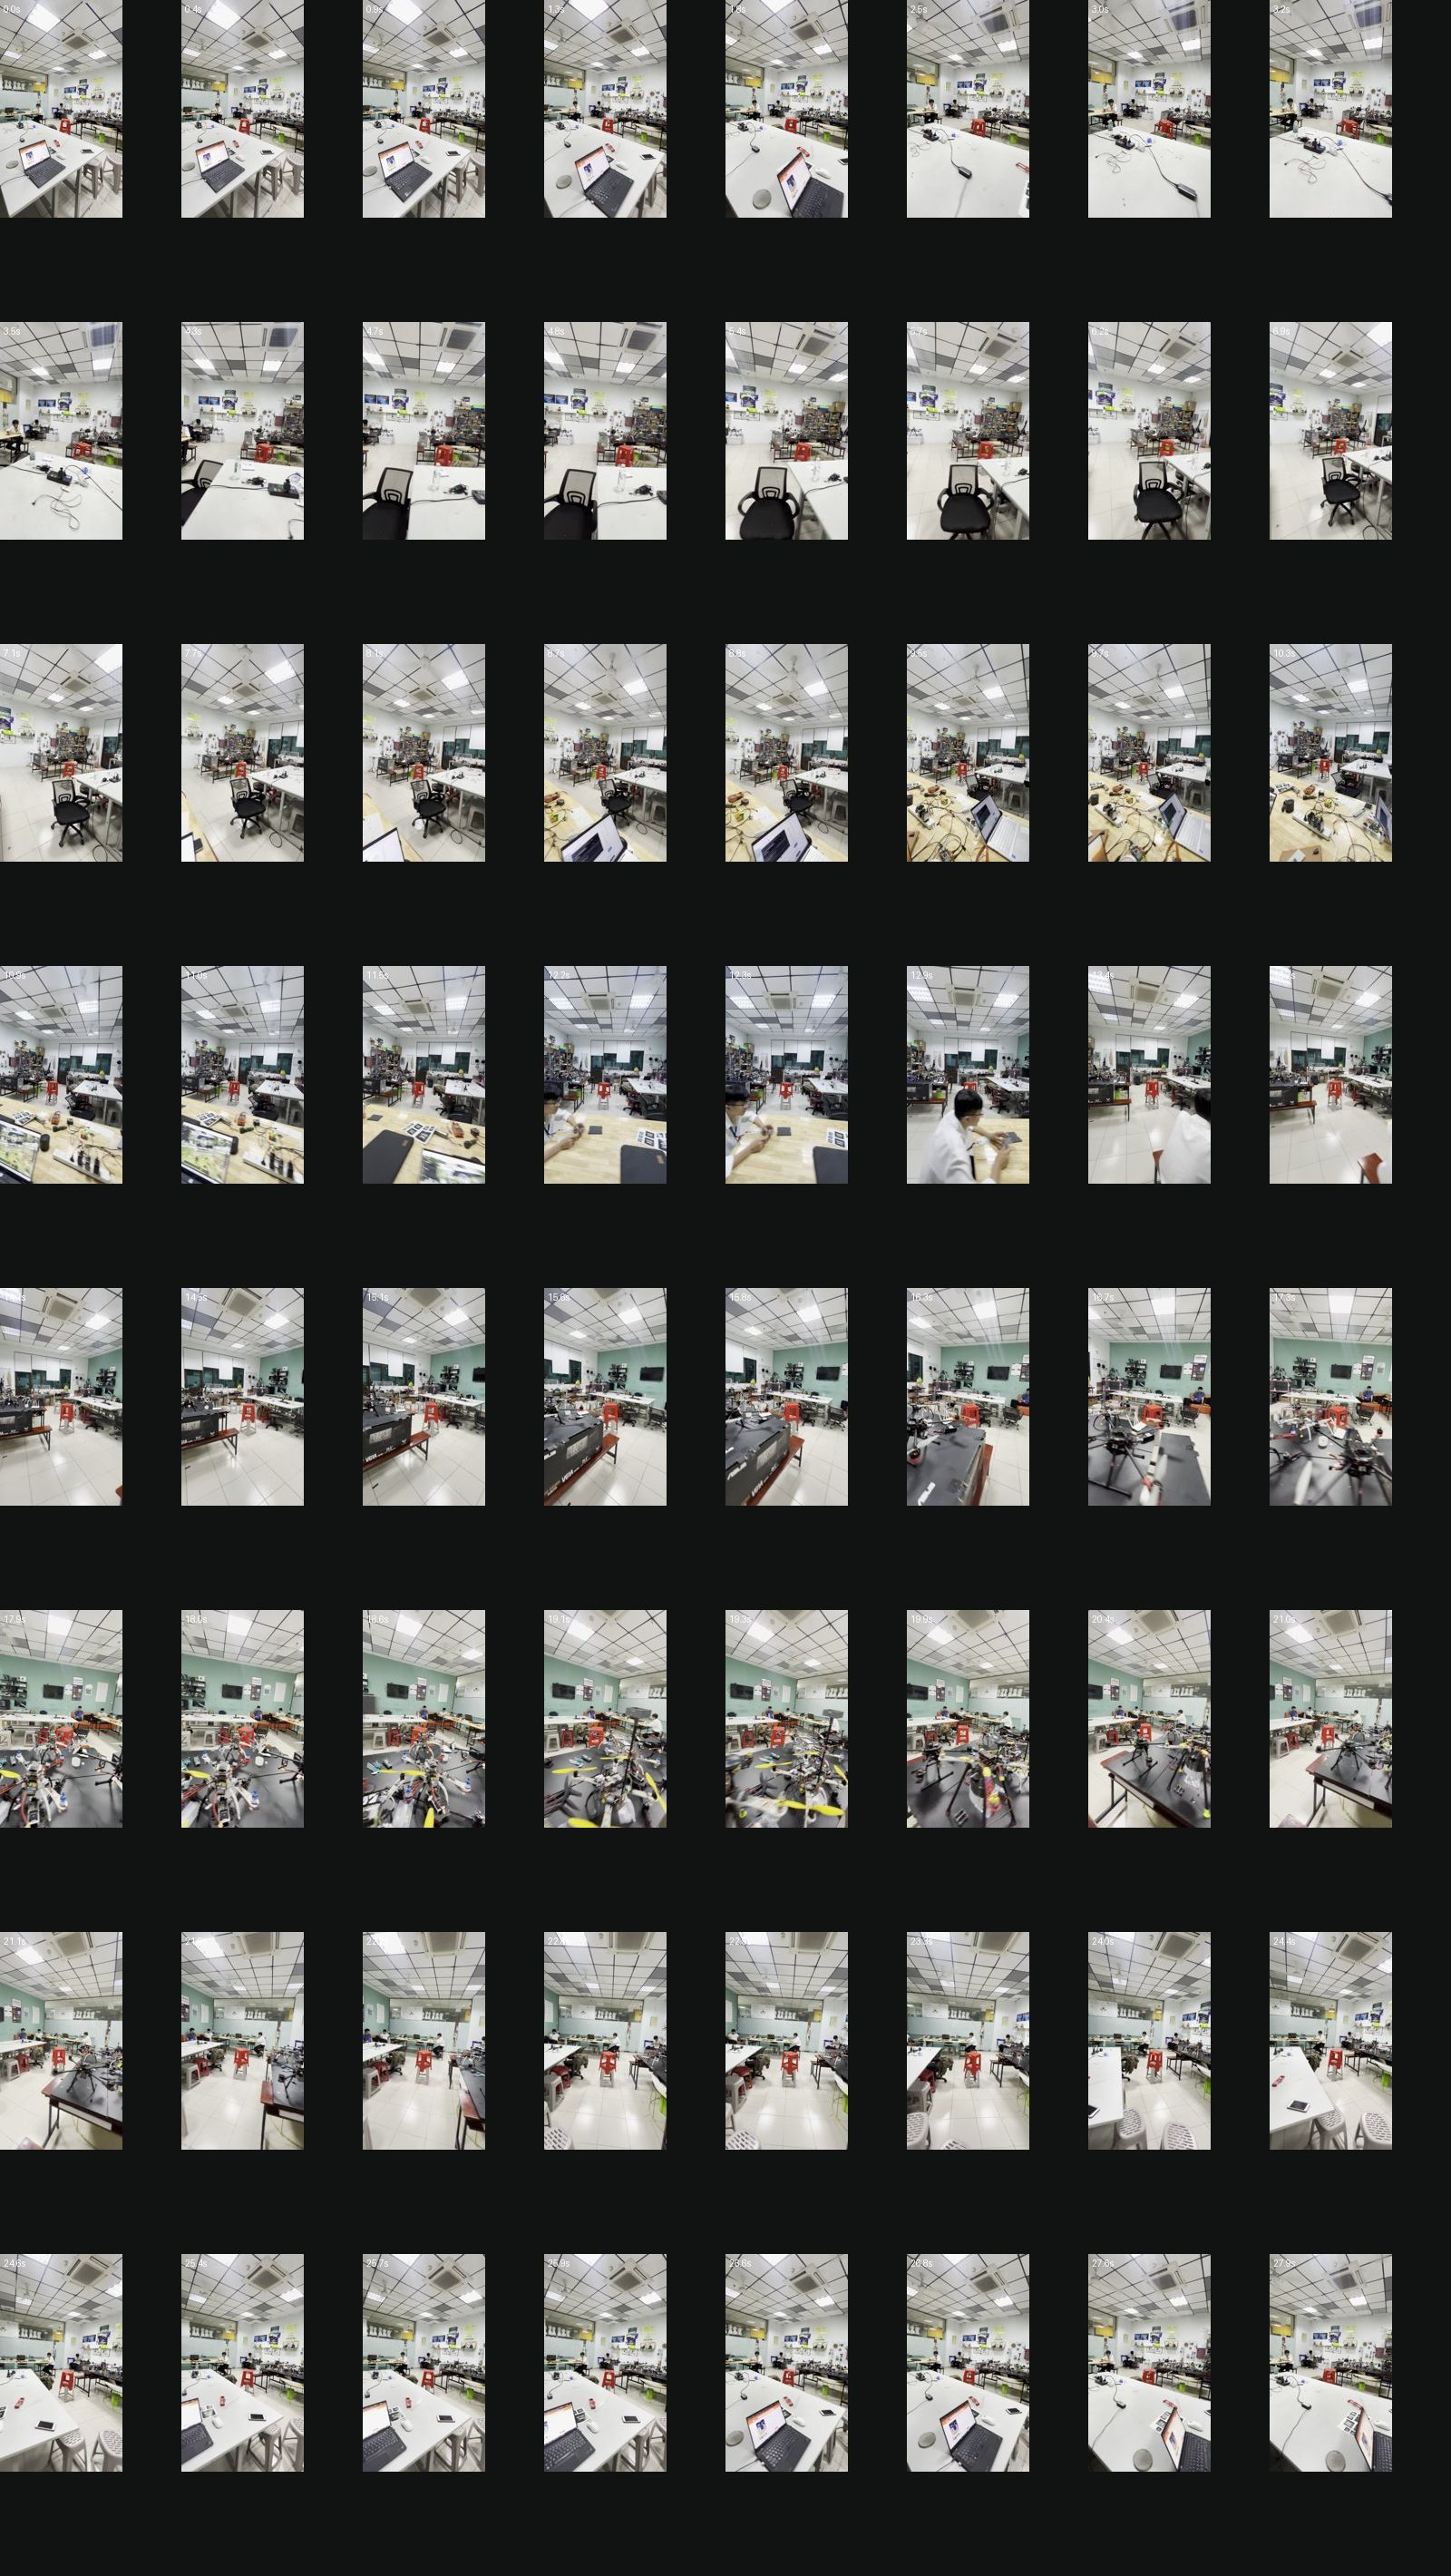

In [4]:
#@title 1 · Video → frame (FFmpeg, chọn frame rõ + có vùng chung)
pipeline("run", *RUN_ARGS, "--stages", "inputs")
video = json.loads((BASE/"project"/"video.json").read_text())
sel = json.loads((BASE/"run"/"selection.json").read_text())
print(f"Video {video['duration_seconds']:.1f} giây · {video['candidate_count']} frame ứng viên · "
      f"chọn {sel['selected_count']} · loại {sel['rejected_count']} ảnh mờ/gần trùng · liên kết đủ: {sel['connected']}")
grid([BASE/"project"/m["thumbnail"] for m in sel["images"]],
     labels=[f"{m.get('timestamp_seconds', 0):.1f}s" for m in sel["images"]])

## 2 · VGGT-1B
Mọi frame đã chọn vào **một** lần suy luận (CUDA, bf16 cho aggregator). VGGT trả về vị trí/hướng camera, intrinsics và depth; điểm được giữ khi có confidence cao và khớp depth với góc nhìn lân cận. Kết quả ghi thành `points.ply`, `cameras.json` và COLMAP `sparse/0`, làm đầu vào cho 3DGUT (không chạy COLMAP SfM).

$ /usr/bin/python3 -m colab.pipeline run --source video --input /content/colab_inputs/IMG_6608.MOV --name img6608_cov --target-frames 64 --reconstruction-steps 10000 --artifixer3d-steps 30000 --trajectory coverage --trajectory-frames 321 --pose-ba --stages vggt


[10:32:50] vggt: Bỏ qua (đã xong ở lần chạy trước)


Bundle adjustment: 64/64 ảnh, chỉnh hướng camera trung bình 0.94° (tối đa 3.24°)
64 camera · 200,000 điểm · suy luận 7.1 giây · VRAM đỉnh 13.9 GB · điểm nhất quán giữa các góc nhìn 94%
Depth tương đối (đỏ = xa, xanh = gần; đen = bị loại vì confidence thấp):


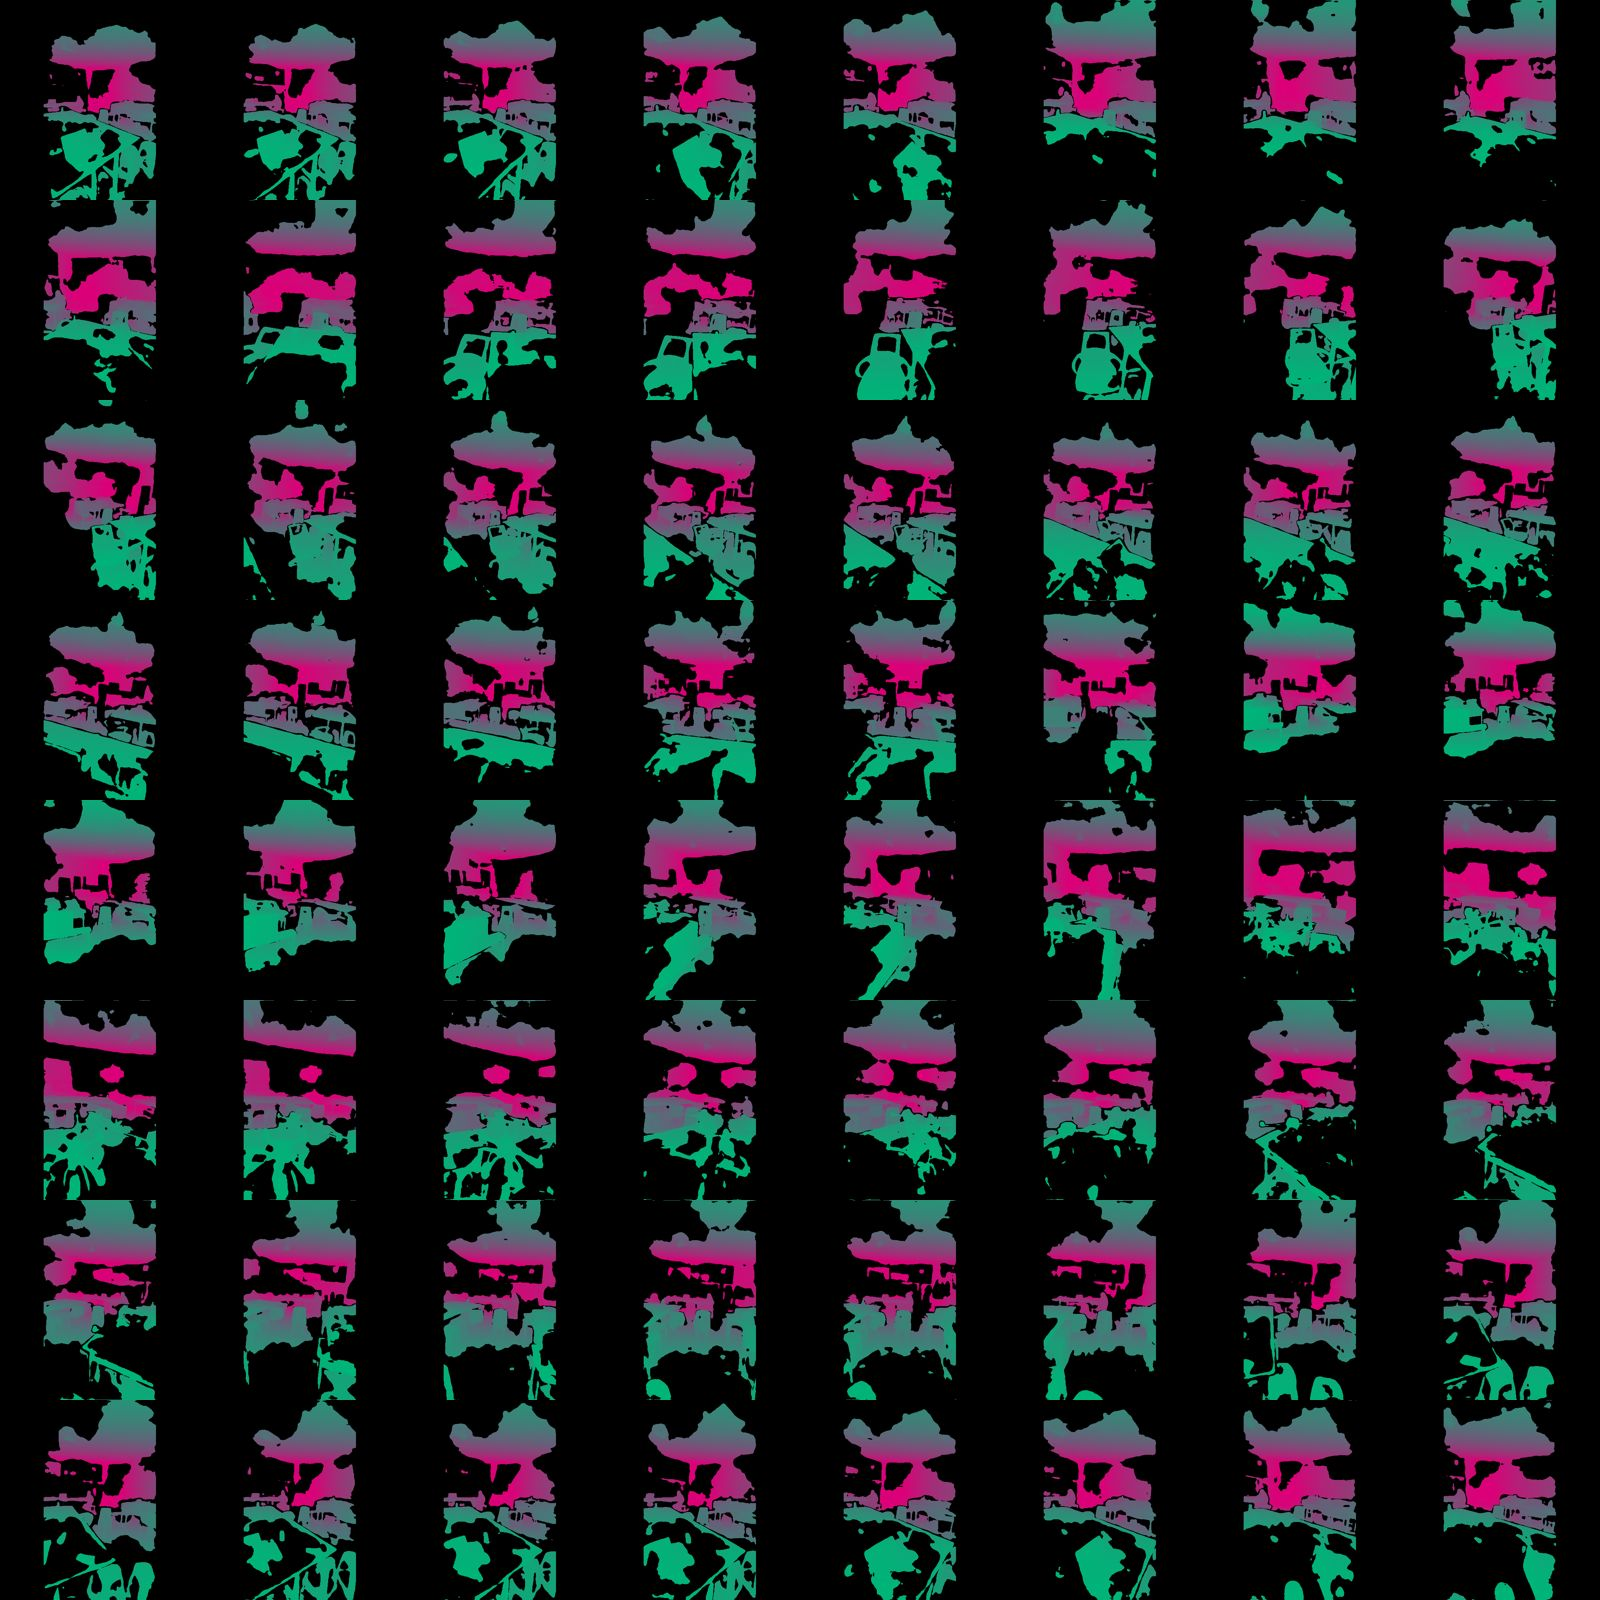

In [5]:
#@title 2 · VGGT-1B: vị trí camera + depth trong một lần suy luận
pipeline("run", *RUN_ARGS, "--stages", "vggt")
geo = json.loads((BASE/"run"/"geometry"/"metrics.json").read_text())
ba_path = BASE/"run"/"geometry"/"pose-ba.json"
if ba_path.exists():
    ba = json.loads(ba_path.read_text())
    print("Bundle adjustment:", f"{ba['registered']}/{ba['images']} ảnh, chỉnh hướng camera trung bình {ba['mean_rotation_change_deg']:.2f}° (tối đa {ba['max_rotation_change_deg']:.2f}°)"
          if ba.get("applied") else f"không áp dụng ({ba.get('reason')})")
print(f"{geo['camera_count']} camera · {geo['point_count']:,} điểm · suy luận {geo['inference_seconds']:.1f} giây · "
      f"VRAM đỉnh {geo['peak_reserved_bytes'] / 2**30:.1f} GB · "
      f"điểm nhất quán giữa các góc nhìn {sum(geo['cross_view_supported_fraction']) / len(geo['cross_view_supported_fraction']):.0%}")
print("Depth tương đối (đỏ = xa, xanh = gần; đen = bị loại vì confidence thấp):")
grid(sorted((BASE/"run"/"geometry").glob("depth_*.png")))

## 3 · 3DGUT → ArtiFixer → ArtiFixer3D
Đây là phần dùng repo [nv-tlabs/ArtiFixer](https://github.com/nv-tlabs/ArtiFixer). 3DGUT dựng splat gốc từ ảnh thật; splat này còn floater và lỗ ở góc chưa quay kỹ. ArtiFixer (video diffusion 1.3B) nhìn các khung render từ một đường đi camera mới và vẽ lại cho sạch; ArtiFixer3D train lại splat từ ảnh thật cộng các khung đã sửa. AI có thể "vẽ thêm" chi tiết không có thật ở vùng thiếu dữ liệu.

$ /usr/bin/python3 -m colab.pipeline run --source video --input /content/colab_inputs/IMG_6608.MOV --name img6608_cov --target-frames 64 --reconstruction-steps 10000 --artifixer3d-steps 30000 --trajectory coverage --trajectory-frames 321 --pose-ba --stages artifixer


[10:32:51] artifixer: Bắt đầu


[10:33:03] artifixer: Scene ArtiFixer: 64 ảnh 544x960, 200000 điểm


[10:33:03] caption: Mã hoá caption bằng text encoder Wan (umt5) — bỏ qua Qwen3-VL 30B


[10:33:03] cmd: $ /usr/bin/python3 /content/3D-ify-everything/colab/artifixer_tools.py caption --out /content/work/img6608_cov/artifixer/prep/img6608_cov/captions/img6608_cov/caption.h5 --text A realistic, high-detail indoor space captured by a handheld camera moving slowly through the room, sharp textures, natural lighting, consistent geometry, no motion blur. --model_id Wan-AI/Wan2.1-T2V-1.3B-Diffusers --images /content/work/img6608_cov/artifixer/colmap/images


...

           /content/work/img6608_cov/artifixer/artifixer3d_3dgrut.p             


           ly...                                                                


PLY -> /content/work/img6608_cov/artifixer/artifixer3d_3dgrut.ply (1000000 Gaussian)


[12:46:40] artifixer: Xong sau 8029 giây


Mặt bằng: camera đã quay (xanh) và quỹ đạo ArtiFixer phải sửa (cam; vòng tròn = xoay 360°)


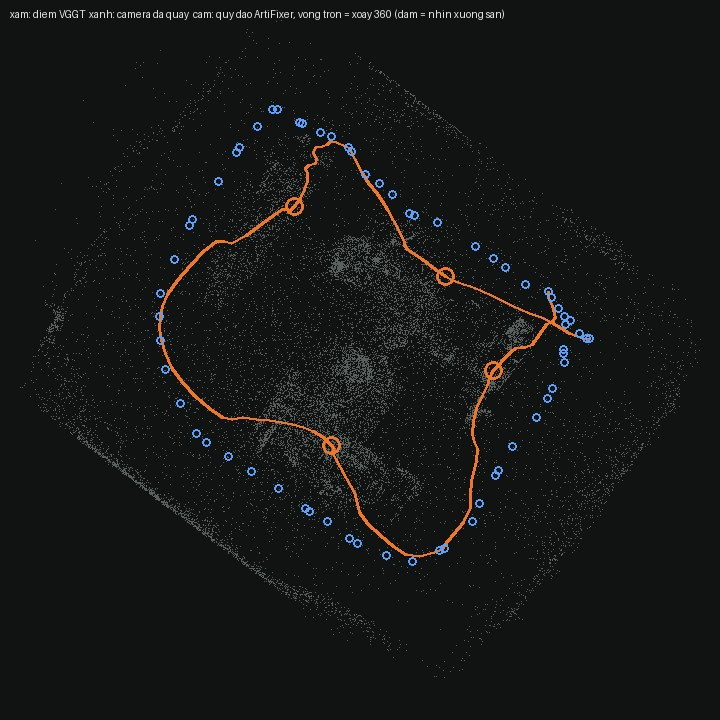

Hàng trên: render 3DGUT gốc · hàng dưới: ArtiFixer đã sửa (8 khung trải đều quỹ đạo, gồm cả lúc xoay/nhìn sàn)


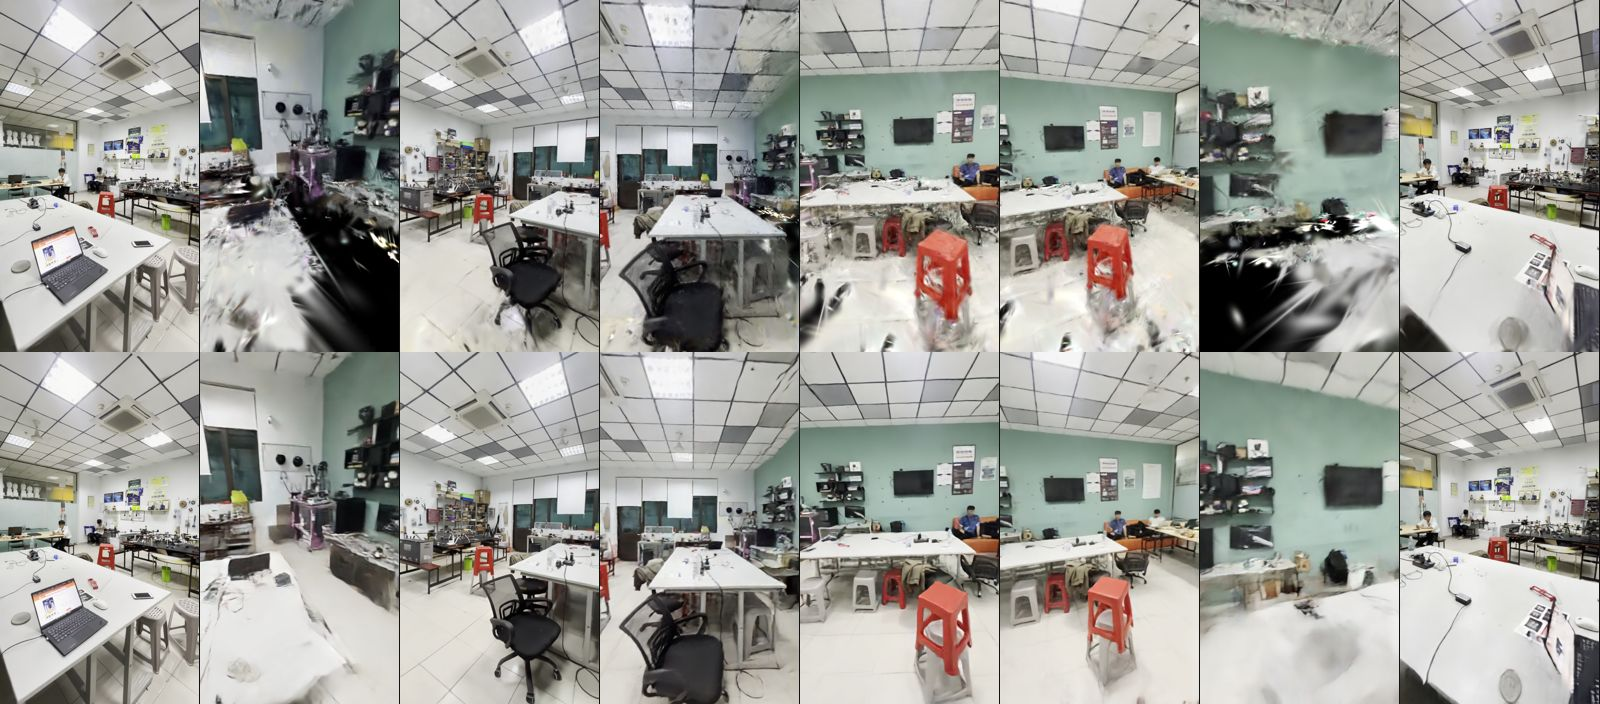

In [6]:
#@title 3 · 3DGUT → ArtiFixer 1.3B → ArtiFixer3D (bước dài nhất)
#@markdown 3a. Dựng scene COLMAP với một calibration chung, tạo quỹ đạo camera mới đi qua các góc đã quay.
#@markdown 3b. Train **3DGUT** MCMC (`RECONSTRUCTION_STEPS`), render quỹ đạo; **MoGe-2** ước lượng scale.
#@markdown 3c. **ArtiFixer 1.3B** sửa các khung render; 3d. **ArtiFixer3D** distill thành splat mới.
pipeline("run", *RUN_ARGS, "--stages", "artifixer")
from colab.pipeline import draw_plan, load_cameras, read_ply_xyzrgb
points, _ = read_ply_xyzrgb(BASE/"run"/"geometry"/"points.ply")
draw_plan(load_cameras(BASE/"run"), points, json.loads((BASE/"artifixer"/"trajectory.json").read_text()), "/tmp/plan.jpg")
print("Mặt bằng: camera đã quay (xanh) và quỹ đạo ArtiFixer phải sửa (cam; vòng tròn = xoay 360°)")
display(Image("/tmp/plan.jpg", width=560))
af = json.loads((BASE/"stages"/"artifixer.json").read_text())
pred = Path(af["pred"]); rendered = pred.parent/"rendered"
frames = sorted(pred.glob("*.png"))
pick = [frames[int(i)] for i in np.linspace(0, len(frames) - 1, 8)]
print("Hàng trên: render 3DGUT gốc · hàng dưới: ArtiFixer đã sửa (8 khung trải đều quỹ đạo, gồm cả lúc xoay/nhìn sàn)")
grid([rendered/p.name for p in pick] + pick, cols=8)

## 4 · Đóng gói
Chuyển PLY của 3DGRUT sang định dạng 3DGS gọn, cắt bỏ Gaussian ngoài vùng đã quay / gần trong suốt / quá lớn / cô lập, và đóng gói viewer tour cùng `results.zip`.

$ /usr/bin/python3 -m colab.pipeline run --source video --input /content/colab_inputs/IMG_6608.MOV --name img6608_cov --target-frames 64 --reconstruction-steps 10000 --artifixer3d-steps 30000 --trajectory coverage --trajectory-frames 321 --pose-ba --stages package


[12:46:41] package: Bắt đầu


[12:48:22] tidy: splat.ply: 1,000,000 → 732,759 Gaussian


[12:49:54] tidy: baseline.ply: 1,000,000 → 805,106 Gaussian


[12:50:25] package: Đã chuẩn bị file cho GitHub release


[12:50:27] package: Đã lưu /content/drive/MyDrive/courtyard-results/img6608_cov-20260925-125025.zip


[12:50:27] package: Kết quả: /content/work/img6608_cov/enhance · /content/work/img6608_cov/results.zip (681.6 MiB)


[12:50:27] package: Xong sau 227 giây


splat.ply: 1,000,000 → 732,759 Gaussian (ngoài vùng 3,596, trong suốt 242,985, quá lớn 448, cô lập 4,479)
baseline.ply: 1,000,000 → 805,106 Gaussian (ngoài vùng 3,954, trong suốt 165,377, quá lớn 74, cô lập 2,925)
Scale metric: Scale factor: 3.980477616883698


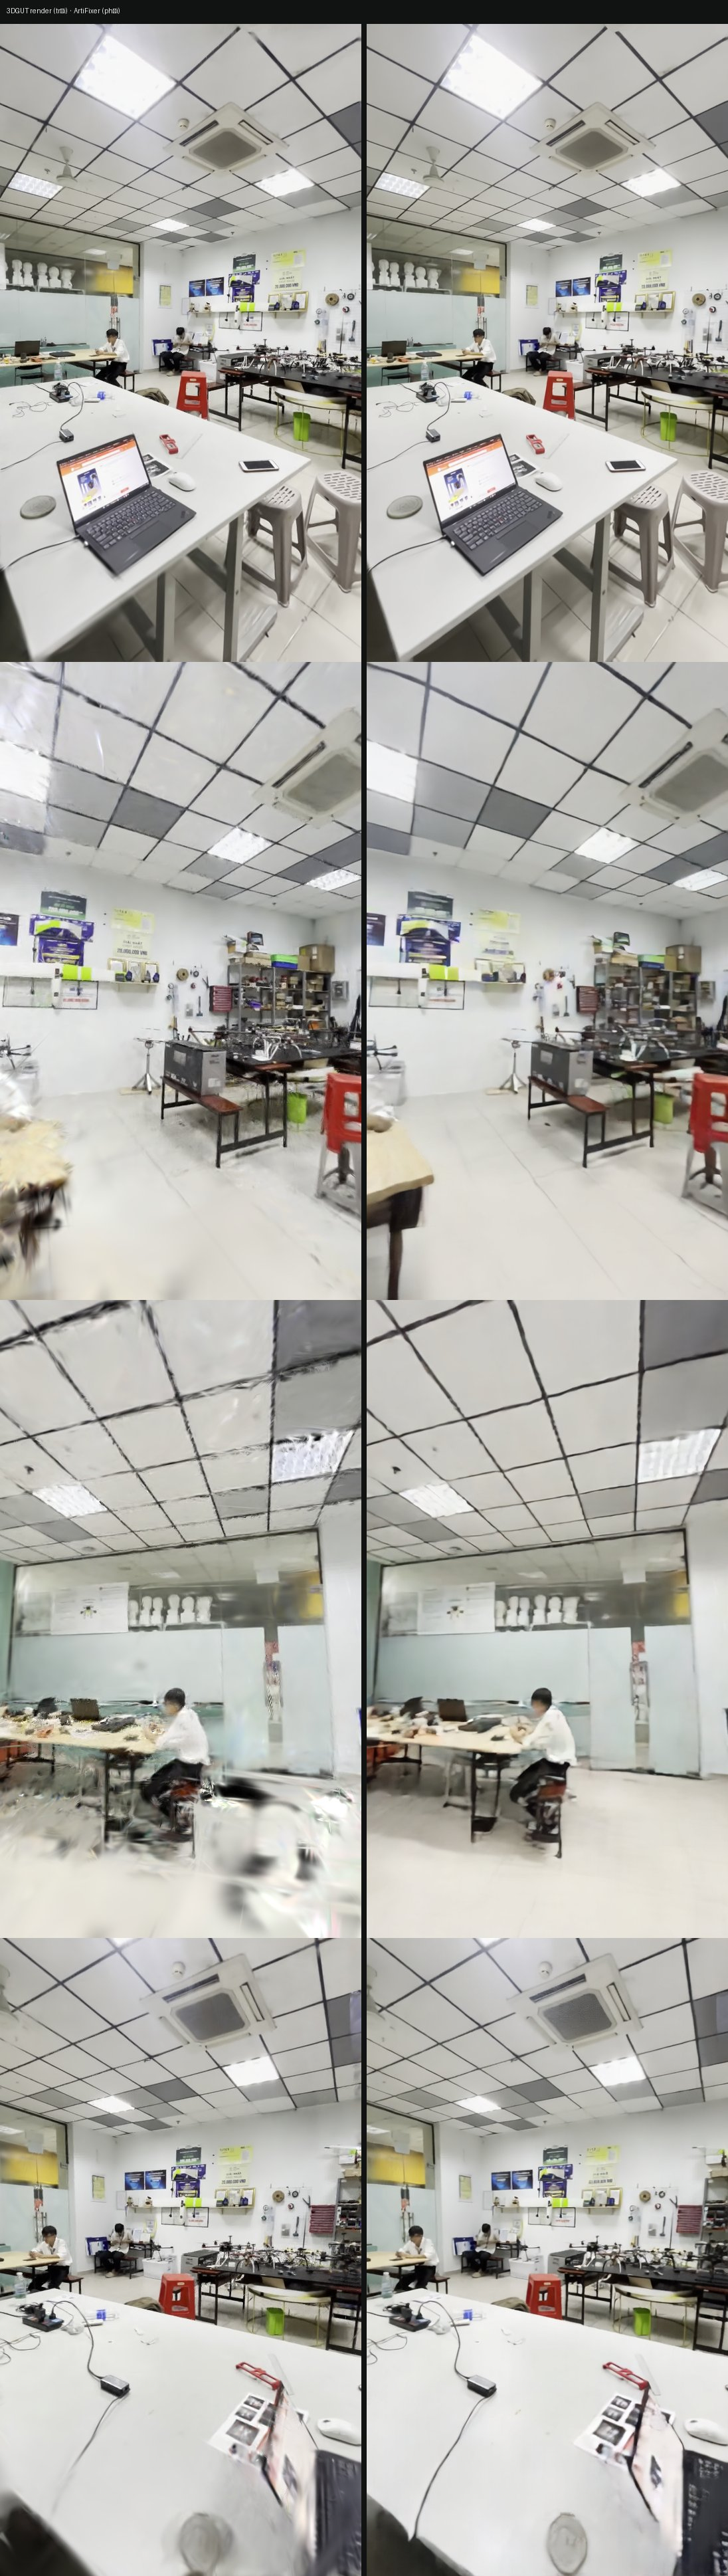

baseline.ply
cameras.json
compare.jpg
fixed_frames/00000.png
fixed_frames/00001.png
fixed_frames/00002.png
fixed_frames/00003.png
fixed_frames/00004.png
fixed_frames/00005.png
fixed_frames/00006.png
fixed_frames/00007.png
fixed_frames/00008.png
fixed_frames/00009.png
fixed_frames/00010.png
fixed_frames/00011.png
fixed_frames/00012.png
fixed_frames/00013.png
fixed_frames/00014.png
fixed_frames/00015.png
fixed_frames/00016.png


In [7]:
#@title 4 · Đóng gói: cắt gọn splat, viewer, results.zip
pipeline("run", *RUN_ARGS, "--stages", "package")
m = json.loads((BASE/"enhance"/"metrics.json").read_text())
for name, t in (m.get("tidy") or {}).items():
    print(f"{name}.ply: {t['before']:,} → {t['after']:,} Gaussian (ngoài vùng {t['outside_box']:,}, trong suốt {t['transparent']:,}, "
          f"quá lớn {t['oversized']:,}, cô lập {t['isolated']:,})")
print("Scale metric:", m.get("metric_scale"))
if (BASE/"enhance"/"compare.jpg").exists(): display(Image(str(BASE/"enhance"/"compare.jpg"), width=900))
print("\n".join(m["files"][:20]))

In [8]:
#@title 5 · Tour 3D trong trình duyệt (kéo để nhìn, bấm vòng tròn trên sàn để đi)
PORT = 8765
subprocess.Popen([sys.executable, "-m", "http.server", str(PORT), "--directory", str(BASE/"enhance")],
                 stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
try:
    from google.colab import output
    output.serve_kernel_port_as_window(PORT, path="/index.html")
except Exception as e:
    print("Mở viewer trong Colab không được ở môi trường này:", e)
    print(f"Tải results.zip, giải nén, chạy `python -m http.server {PORT}` trong thư mục đó rồi mở http://127.0.0.1:{PORT}")

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [9]:
#@title 6 · Lưu kết quả
zip_path = BASE/"results.zip"
print(f"{zip_path} · {zip_path.stat().st_size / 2**20:.0f} MiB (đã tự sao lưu vào Drive/courtyard-results nếu Drive được mount)")
try:
    from google.colab import files
    files.download(str(zip_path))
except Exception as e:
    print("Không tải trực tiếp được ở môi trường này:", e)

/content/work/img6608_cov/results.zip · 682 MiB (đã tự sao lưu vào Drive/courtyard-results nếu Drive được mount)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>